In [1]:
print("Alhamdullilah")

Alhamdullilah


In [6]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/wine_clustering.csv")
print(df.shape)
print(df.info())
df.head()

(178, 13)
<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 18.2 KB
None


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [7]:
# Check for null


Alcohol                 0
Malic_Acid              0
Ash                     0
Ash_Alcanity            0
Magnesium               0
Total_Phenols           0
Flavanoids              0
Nonflavanoid_Phenols    0
Proanthocyanins         0
Color_Intensity         0
Hue                     0
OD280                   0
Proline                 0
dtype: int64

In [8]:
from sklearn.datasets import load_wine

wine = load_wine()

X = pd.DataFrame(wine.data, columns=wine.feature_names)

print(X.shape)
print(X.head())
print(X.info())

(178, 13)
   alcohol  malic_acid   ash  ...   hue  od280/od315_of_diluted_wines  proline
0    14.23        1.71  2.43  ...  1.04                          3.92   1065.0
1    13.20        1.78  2.14  ...  1.05                          3.40   1050.0
2    13.16        2.36  2.67  ...  1.03                          3.17   1185.0
3    14.37        1.95  2.50  ...  0.86                          3.45   1480.0
4    13.24        2.59  2.87  ...  1.04                          2.93    735.0

[5 rows x 13 columns]
<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-nu

In [9]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


In [10]:
# Standardize the features
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


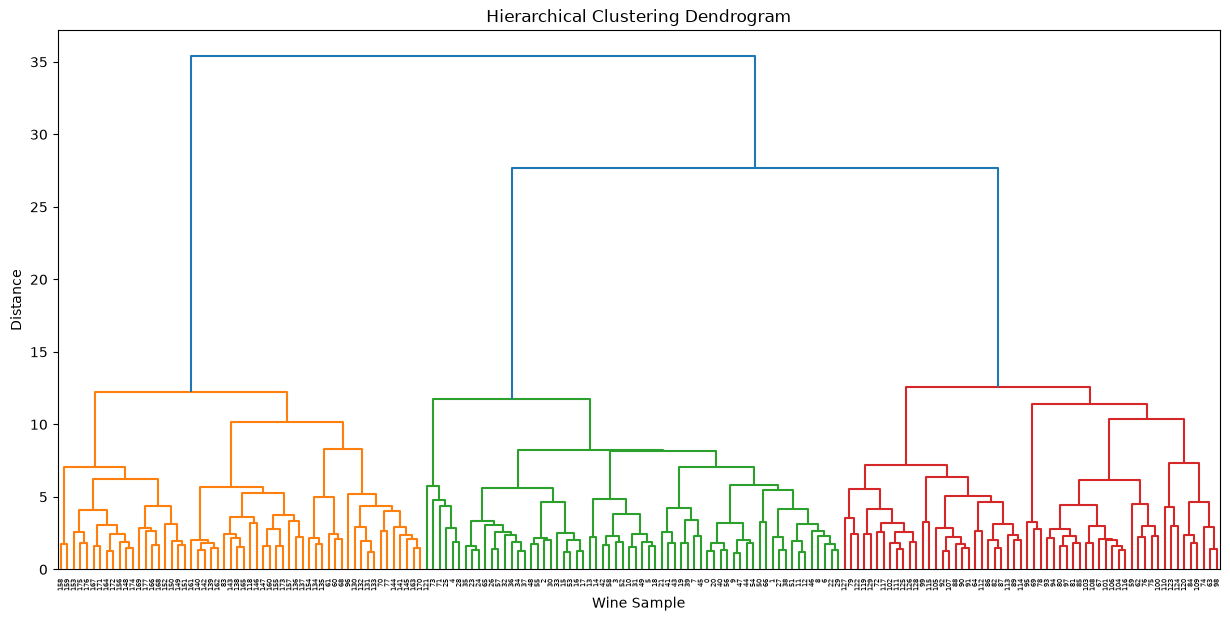

In [11]:
# Understanding Hierarchical clustering
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

Z = linkage(
    X_scaled,
    method="ward"
)

plt.figure(figsize=(15, 7))

dendrogram(Z)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Wine Sample")
plt.ylabel("Distance")

plt.show()

In [14]:
# Agglomerative Clustering model
from sklearn.cluster import AgglomerativeClustering

cluster_model= AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

clusters = cluster_model.fit_predict(X_scaled)

# print(clusters)

result = X.copy()

result['cluster'] = clusters

print(result.head())
print(result['cluster'].value_counts().sort_index())

   alcohol  malic_acid   ash  ...  od280/od315_of_diluted_wines  proline  cluster
0    14.23        1.71  2.43  ...                          3.92   1065.0        2
1    13.20        1.78  2.14  ...                          3.40   1050.0        2
2    13.16        2.36  2.67  ...                          3.17   1185.0        2
3    14.37        1.95  2.50  ...                          3.45   1480.0        2
4    13.24        2.59  2.87  ...                          2.93    735.0        2

[5 rows x 14 columns]
cluster
0    58
1    56
2    64
Name: count, dtype: int64


In [17]:
from sklearn.metrics import silhouette_score

scores = {}

for k in range(2, 8):
    model = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        clusters
    )

    scores[k] = score

    print(f"k={k}, Silhouette Score: {score:.4f}")

k=2, Silhouette Score: 0.2774
k=3, Silhouette Score: 0.2774
k=4, Silhouette Score: 0.2774
k=5, Silhouette Score: 0.2774
k=6, Silhouette Score: 0.2774
k=7, Silhouette Score: 0.2774


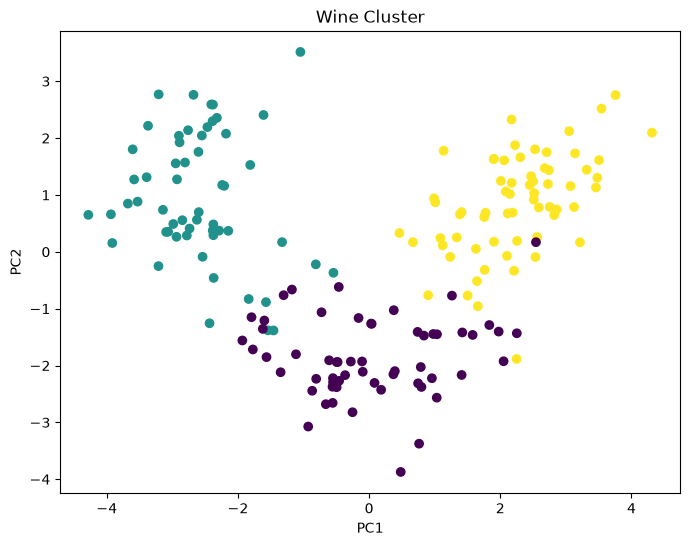

In [28]:
# Visualize the cluster
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Wine Cluster")

plt.show()
# print(X_pca)

In [23]:
# Understand what cluster look like
clustered = X.copy()

clustered["cluster"] = clusters

clustered.groupby("cluster").mean().T

cluster,0,1,2
alcohol,12.203966,13.061607,13.669219
malic_acid,1.938966,3.166607,1.970000
ash,2.215172,2.412857,2.463125
alcalinity_of_ash,20.208621,21.003571,17.528125
magnesium,92.551724,99.857143,106.156250
total_phenols,2.262931,1.694286,2.850000
flavanoids,2.088103,0.847857,3.009688
nonflavanoid_phenols,0.355345,0.449464,0.291094
proanthocyanins,1.686552,1.129286,1.908125
color_intensity,2.895345,6.850179,5.450000


In [24]:
# Optional validation against the known labels
from sklearn.metrics import adjusted_rand_score

true_labels = wine.target

ari = adjusted_rand_score(true_labels, clusters)

print("Adjusted Rand Index: ", ari)

Adjusted Rand Index:  0.7899332213582837


In [26]:
true_labels

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2])